# Customer Churn Prediction
Predicting whether a telecom customer will churn (leave) based on their account and service usage features using classification models.

In [36]:
# import libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Load and Explore the Data

In [37]:
df = pd.read_csv("./data/customer_churn.csv")
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [38]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [39]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Data Visualization

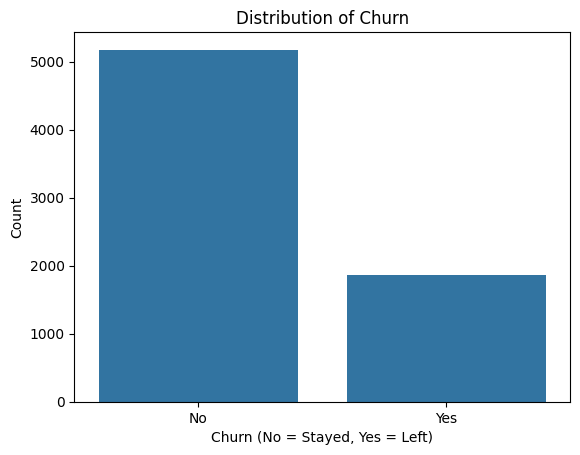

In [40]:
sns.countplot(x=df["Churn"])
plt.title("Distribution of Churn")
plt.xlabel("Churn (No = Stayed, Yes = Left)")
plt.ylabel("Count")
plt.show()

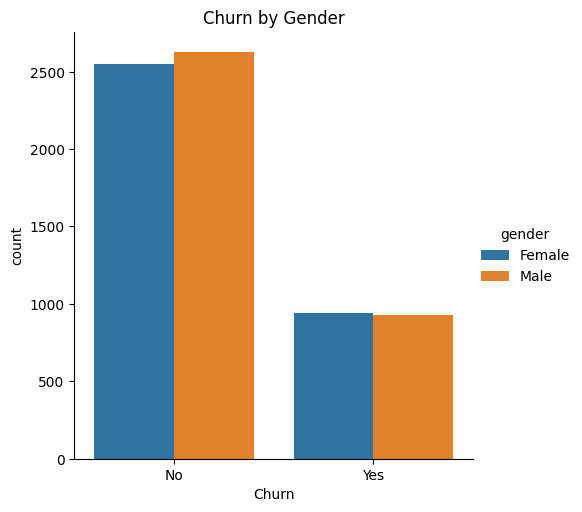

In [41]:
sns.catplot(data=df, x="Churn", hue="gender", kind="count")
plt.title("Churn by Gender")
plt.show()

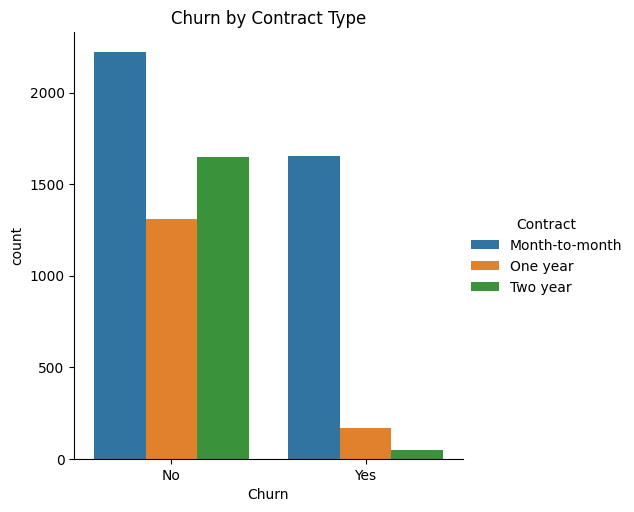

In [42]:
sns.catplot(data=df, x="Churn", hue="Contract", kind="count")
plt.title("Churn by Contract Type")
plt.show()

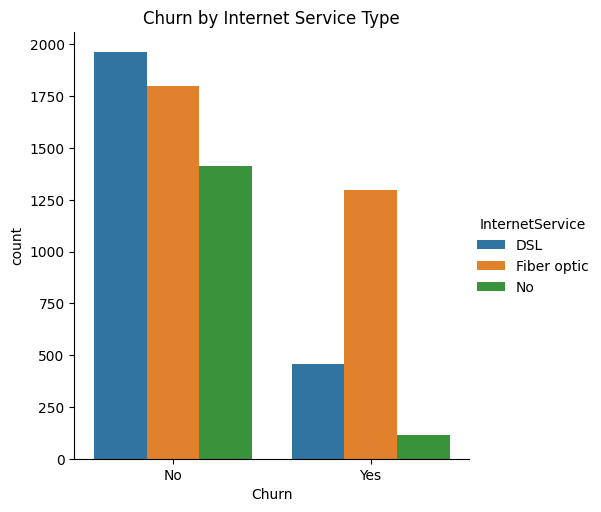

In [43]:
sns.catplot(data=df, x="Churn", hue="InternetService", kind="count")
plt.title("Churn by Internet Service Type")
plt.show()

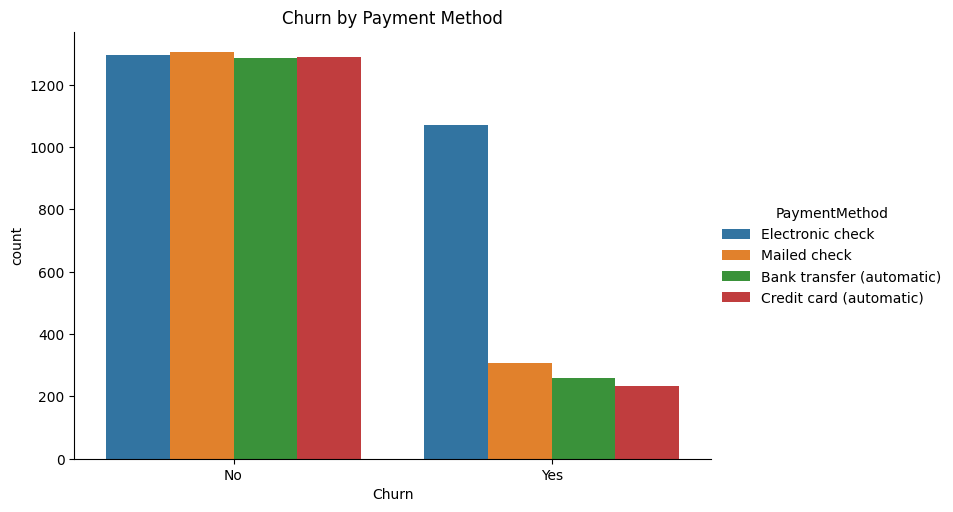

In [44]:
sns.catplot(data=df, x="Churn", hue="PaymentMethod", kind="count", height=5, aspect=1.5)
plt.title("Churn by Payment Method")
plt.show()

## Data Preprocessing

In [45]:
# drop customerID column (not useful for prediction)
df = df.drop("customerID", axis=1)

### Encoding Categorical Features

In [46]:
# encode the target variable
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# encode all other categorical columns using LabelEncoder
label_encoders = {}
categorical_cols = df.select_dtypes(include=["object", "string"]).columns

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925,1


### Correlation Heatmap

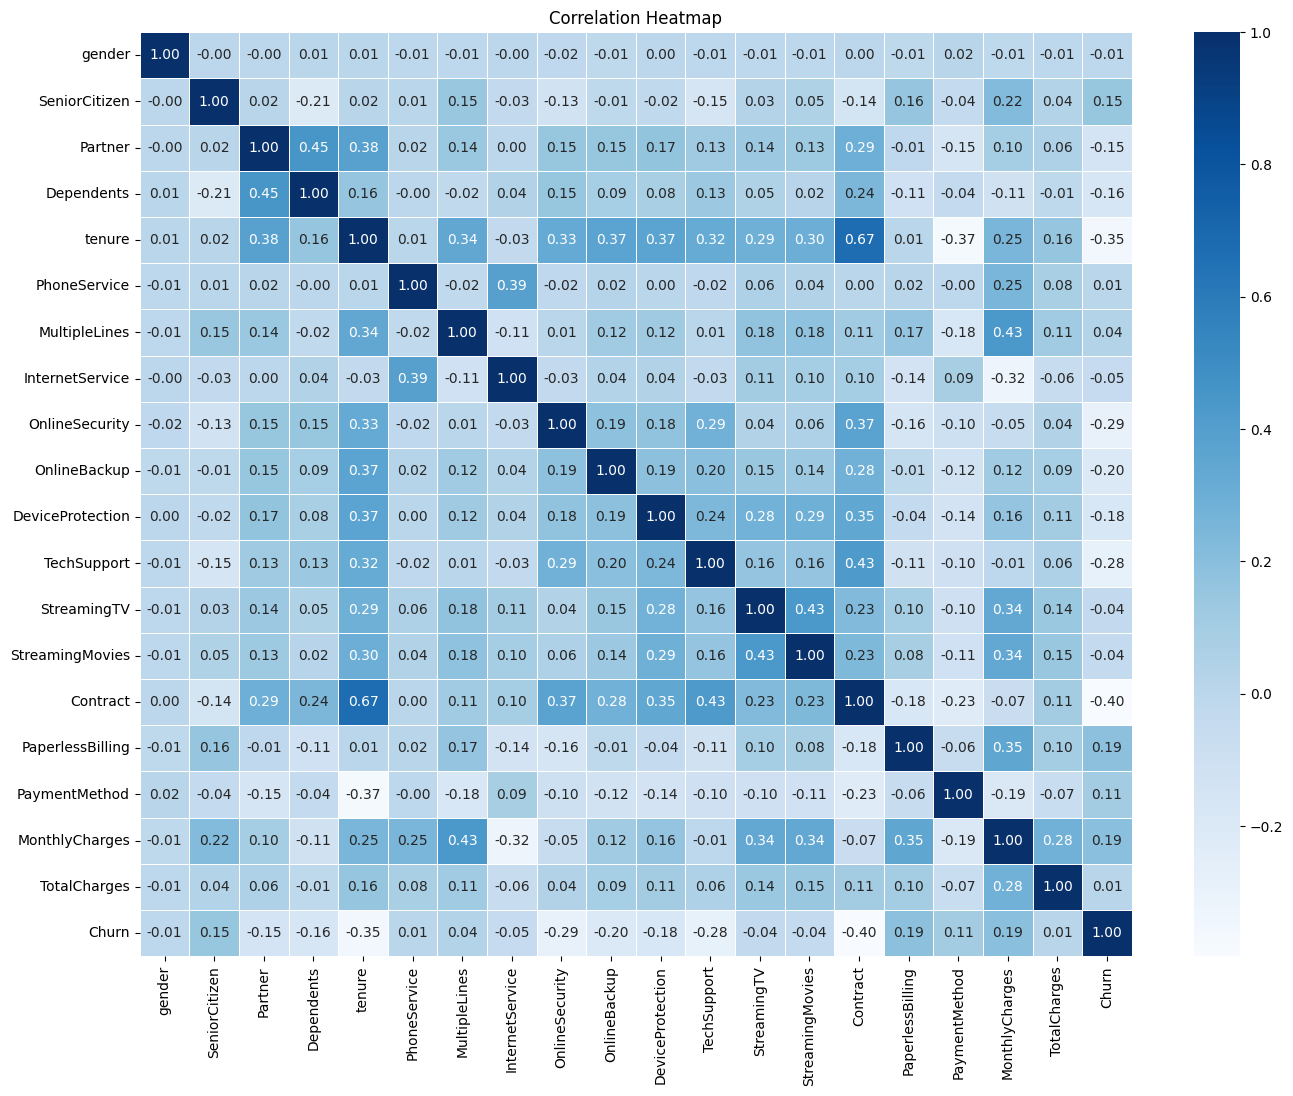

In [47]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

### Feature Scaling

In [48]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,-1.009559,-0.439916,1.034530,-0.654012,-1.277445,-3.054010,0.062723,-1.183234,-0.918838,1.242550,-1.027910,-0.925262,-1.113495,-1.121405,-0.828207,0.829798,0.398558,-1.160323,-0.398608
1,0.990532,-0.439916,-0.966622,-0.654012,0.066327,0.327438,-0.991588,-1.183234,1.407321,-1.029919,1.245111,-0.925262,-1.113495,-1.121405,0.371271,-1.205113,1.334863,-0.259629,-0.948762
2,0.990532,-0.439916,-0.966622,-0.654012,-1.236724,0.327438,-0.991588,-1.183234,1.407321,1.242550,-1.027910,-0.925262,-1.113495,-1.121405,-0.828207,0.829798,1.334863,-0.362660,-1.641883
3,0.990532,-0.439916,-0.966622,-0.654012,0.514251,-3.054010,0.062723,-1.183234,1.407321,-1.029919,1.245111,1.396299,-1.113495,-1.121405,0.371271,-1.205113,-1.474052,-0.746535,-0.983710
4,-1.009559,-0.439916,-0.966622,-0.654012,-1.236724,0.327438,-0.991588,0.172250,-0.918838,-1.029919,-1.027910,-0.925262,-1.113495,-1.121405,-0.828207,0.829798,0.398558,0.197365,-1.235224


### Split the Data

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## Model Training and Evaluation

### Logistic Regression

In [50]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print(f"Training Accuracy: {accuracy_score(y_train, model_lr.predict(X_train)):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print()
print(classification_report(y_test, y_pred_lr))

Training Accuracy: 0.8044
Test Accuracy: 0.8162

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.69      0.56      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



### Random Forest Classifier

In [51]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print(f"Training Accuracy: {accuracy_score(y_train, model_rf.predict(X_train)):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print()
print(classification_report(y_test, y_pred_rf))

Training Accuracy: 0.9984
Test Accuracy: 0.8006

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.67      0.49      0.57       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



### Support Vector Machine (SVM)

In [52]:
model_svm = SVC(kernel="rbf")
model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)

print(f"Training Accuracy: {accuracy_score(y_train, model_svm.predict(X_train)):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print()
print(classification_report(y_test, y_pred_svm))

Training Accuracy: 0.8216
Test Accuracy: 0.8070

              precision    recall  f1-score   support

           0       0.83      0.92      0.88      1036
           1       0.70      0.48      0.57       373

    accuracy                           0.81      1409
   macro avg       0.76      0.70      0.72      1409
weighted avg       0.80      0.81      0.79      1409



### Gradient Boosting Classifier

In [53]:
model_gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
model_gb.fit(X_train, y_train)

y_pred_gb = model_gb.predict(X_test)

print(f"Training Accuracy: {accuracy_score(y_train, model_gb.predict(X_train)):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print()
print(classification_report(y_test, y_pred_gb))

Training Accuracy: 0.8241
Test Accuracy: 0.8112

              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1036
           1       0.69      0.53      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## Confusion Matrices

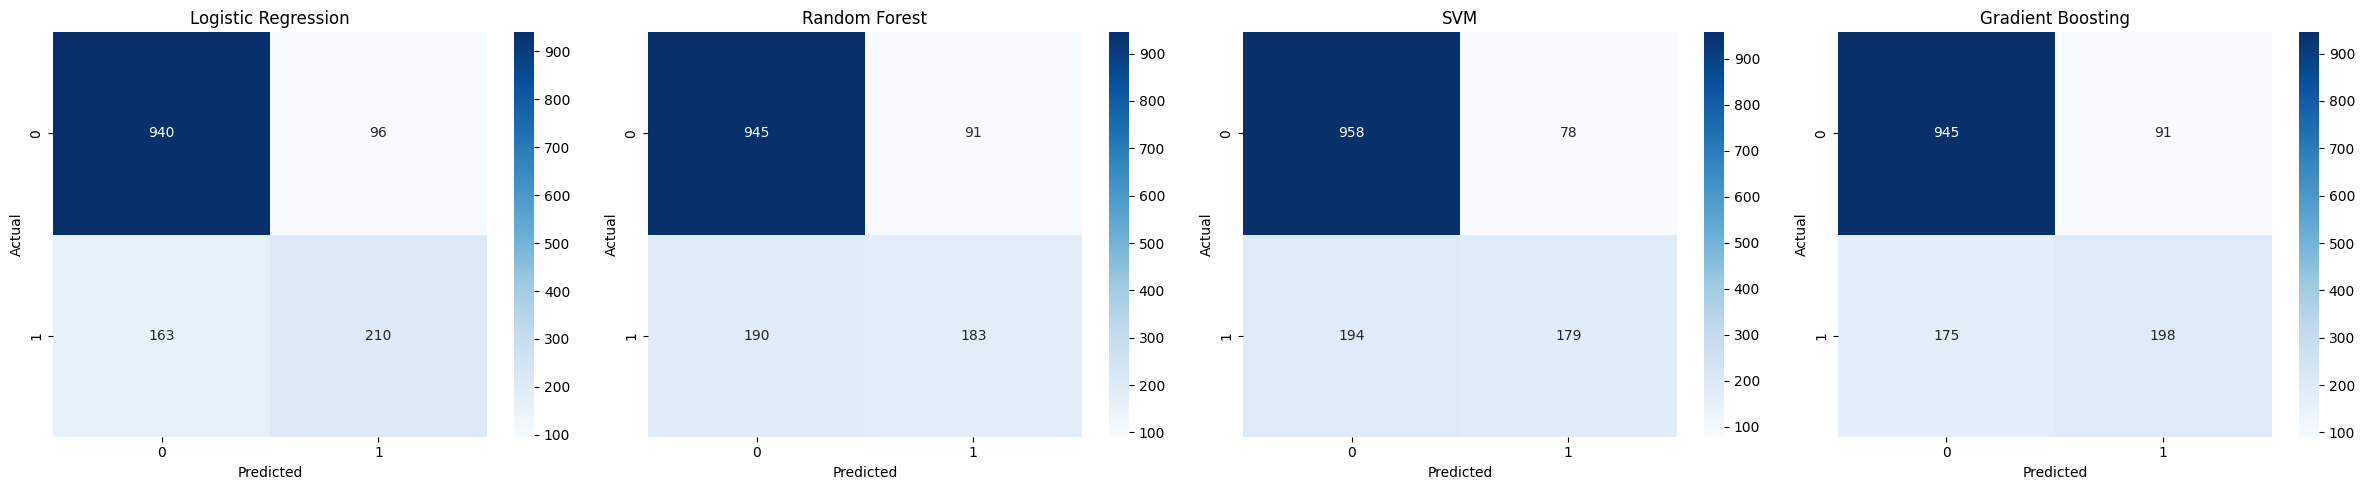

In [54]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

models = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "Gradient Boosting": y_pred_gb
}

for ax, (name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"{name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Test with a Sample Customer

In [55]:
# pick a sample from the test set
sample_index = X_test.index[0]
sample = X_test.iloc[[0]]

prediction = model_gb.predict(sample)
actual = y_test.iloc[0]

print(f"Predicted: {'Churn' if prediction[0] == 1 else 'No Churn'}")
print(f"Actual: {'Churn' if actual == 1 else 'No Churn'}")

Predicted: Churn
Actual: Churn
